# Phase-length `q` tradeoff for Private SpiderBoost on Criteo

Train Algorithm 2 of Arora et al. (ICML 2023) for several phase lengths `q` at a fixed privacy budget `ε`, and compare final test ROC-AUC.

`q` controls how the noise budget is split between anchor steps (large fresh gradients, noise `σ₁`) and variation steps (small gradient differences, noise `min(σ₂·‖Δw‖, σ̂₂)`):
- Small `q` → many anchor steps → fresh estimates but each one is noisier (because `σ₁ ∝ max(1/b₁, √T/(qn))`).
- Large `q` → few anchor steps → each anchor is less noisy, but the running estimate drifts further between refreshes.

Edit `Q_VALUES` to sweep different phase lengths.

In [1]:
import sys, pathlib

def _find_project():
    here = pathlib.Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / 'src' / 'datasets.py').is_file():
            return p
    raise RuntimeError(f'Could not locate project root (no src/datasets.py) from {here}')

PROJECT = _find_project()
if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))

from src.datasets import load_dataset
from src.privacy_accountant import compute_noise_scales
from src.train import TrainConfig, train, evaluate_auc
from src import visualization as viz
import pandas as pd

In [2]:
DEVICE = 'cpu'  # 'cpu' or 'cuda'
from src.device import resolve_device
print(f'Using device: {resolve_device(DEVICE)}')

Using device: cpu:0


## 1. Load data (once)

In [3]:
DATA_PATH = PROJECT / 'data' / 'criteo_1M.parquet'
FIGS_DIR  = PROJECT / 'figs'
FIGS_DIR.mkdir(exist_ok=True)

data = load_dataset("criteo_1M", data_dir=DATA_PATH.parent, test_fraction=0.2, seed=0, device=DEVICE)
n_train, d = data.x_train.shape
print(f'train: {data.x_train.shape}   test: {data.x_test.shape}')

train: (800000, 13)   test: (200000, 13)


## 2. Sweep configuration

Edit `Q_VALUES` to change the phase lengths that are tested. `BASE` holds everything else.

In [4]:
Q_VALUES = [5, 10, 30, 100, 300]

BASE = dict(
    epsilon     = 10.0,
    delta       = 1 / (1.1 * n_train),
    L0          = 3.0,
    L1          = 5.0,
    T           = 1500,
    b1          = 8192,
    b2          = 512,
    eta         = 0.01,
    hidden_dims = (64, 32),
    seed        = 0,
)
BASE

{'epsilon': 10.0,
 'delta': 1.1363636363636362e-06,
 'L0': 3.0,
 'L1': 5.0,
 'T': 1500,
 'b1': 8192,
 'b2': 512,
 'eta': 0.01,
 'hidden_dims': (64, 32),
 'seed': 0}

## 3. Run the sweep

In [5]:
records = []
for q in Q_VALUES:
    cfg = TrainConfig(q=q, device=DEVICE, **BASE)
    noise = compute_noise_scales(
        L0=cfg.L0, L1=cfg.L1, epsilon=cfg.epsilon, delta=cfg.delta,
        T=cfg.T, q=cfg.q, n=n_train, b1=cfg.b1, b2=cfg.b2,
    )
    print(f'\n--- q = {q} ---')
    print(f'    sigma1={noise.sigma1:.3e}  sigma2={noise.sigma2:.3e}  sigma2_hat={noise.sigma2_hat:.3e}')
    res = train(
        data.x_train, data.y_train,
        data.x_test,  data.y_test,
        cfg, noise, progress_every=0,
    )
    auc_random = evaluate_auc(res.params_random, data.x_test, data.y_test)
    auc_final  = evaluate_auc(res.params_final,  data.x_test, data.y_test)
    records.append({
        'q':               q,
        'auc_random':      auc_random,
        'auc_final':       auc_final,
        'sigma1':          noise.sigma1,
        'sigma2_hat':      noise.sigma2_hat,
        'final_grad_norm': res.history.grad_norm[-1],
        'final_train_loss': res.history.train_loss[-1],
        'wall_time_s':     res.history.wall_time_s,
    })
    print(f'    AUC(w_bar)={auc_random:.4f}   AUC(w_T)={auc_final:.4f}   ({res.history.wall_time_s:.1f} s)')


--- q = 5 ---
    sigma1=1.355e-04  sigma2=3.613e-03  sigma2_hat=4.336e-03
    AUC(w_bar)=0.6839   AUC(w_T)=0.6853   (30.6 s)

--- q = 10 ---
    sigma1=1.355e-04  sigma2=3.613e-03  sigma2_hat=4.336e-03
    AUC(w_bar)=0.6839   AUC(w_T)=0.6854   (17.6 s)

--- q = 30 ---
    sigma1=1.355e-04  sigma2=3.613e-03  sigma2_hat=4.336e-03
    AUC(w_bar)=0.6841   AUC(w_T)=0.6856   (12.6 s)

--- q = 100 ---
    sigma1=1.355e-04  sigma2=3.613e-03  sigma2_hat=4.336e-03
    AUC(w_bar)=0.6843   AUC(w_T)=0.6860   (10.4 s)

--- q = 300 ---
    sigma1=1.355e-04  sigma2=3.613e-03  sigma2_hat=4.336e-03
    AUC(w_bar)=0.6843   AUC(w_T)=0.6850   (10.5 s)


## 4. Results table

In [6]:
df = pd.DataFrame(records)
df

,q,auc_random,auc_final,sigma1,sigma2_hat,final_grad_norm,final_train_loss,wall_time_s
0,5,0.683875,0.685329,0.000135,0.004336,0.022879,0.551839,30.566765
1,10,0.683874,0.685363,0.000135,0.004336,0.023032,0.551651,17.572609
2,30,0.684142,0.685611,0.000135,0.004336,0.023060,0.550021,12.640038
3,100,0.684349,0.685990,0.000135,0.004336,0.025596,0.546316,10.372670
4,300,0.684271,0.685040,0.000135,0.004336,0.025231,0.546842,10.488869


## 5. Plot

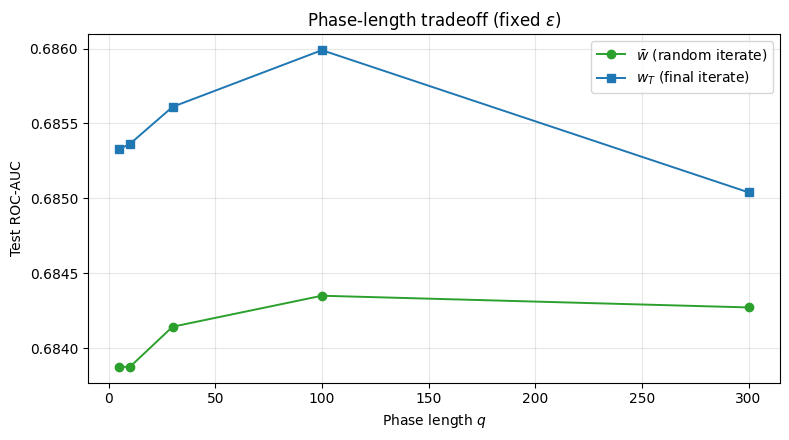

In [7]:
_ = viz.plot_q_sweep(
    df['q'].tolist(),
    df['auc_random'].tolist(),
    df['auc_final'].tolist(),
    FIGS_DIR / 'phase_length_q_tradeoff.png',
)